In [7]:
pip install opencv-python mediapipe pydub scipy


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
import mediapipe as mp
from pydub import AudioSegment
from pydub.playback import play
import numpy as np
from scipy.io.wavfile import write
import io
import threading

# Initialize Mediapipe Hand Detector
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(min_detection_confidence=0.7, min_tracking_confidence=0.7)

# Generate Piano Notes Programmatically
def generate_note(note_freq, duration=0.5, sample_rate=44100):
    """Generate a sine wave representing a piano note."""
    t = np.linspace(0, duration, int(sample_rate * duration), False)
    note_wave = 0.5 * np.sin(2 * np.pi * note_freq * t)
    return (note_wave * 32767).astype(np.int16)

def save_note_to_buffer(note_freq):
    """Save the generated note to an in-memory buffer."""
    note = generate_note(note_freq)
    buffer = io.BytesIO()
    write(buffer, 44100, note)
    buffer.seek(0)
    return AudioSegment.from_wav(buffer)

# Piano Notes Frequencies (in Hz)
piano_notes = {
    "C": 261.63,
    "D": 293.66,
    "E": 329.63,
    "F": 349.23,
    "G": 392.00,
    "A": 440.00,
    "B": 493.88,
}

# Load Notes into Memory (avoiding file I/O delays)
notes = {key: save_note_to_buffer(freq) for key, freq in piano_notes.items()}

# Piano Key Regions (x-coordinates)
keys = {
    "C": (0, 100),
    "D": (100, 200),
    "E": (200, 300),
    "F": (300, 400),
    "G": (400, 500),
    "A": (500, 600),
    "B": (600, 700),
}

# Open Webcam
cap = cv2.VideoCapture(0)

# To avoid multiple simultaneous notes playing
last_played = None

def detect_key(finger_x):
    """Detect which piano key is pressed based on finger x-coordinate."""
    for key, (start, end) in keys.items():
        if start < finger_x < end:
            return key
    return None

def play_note_in_thread(note):
    """Play note in a separate thread to avoid blocking."""
    threading.Thread(target=play, args=(note,)).start()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)  # Flip for mirror effect
    height, width, _ = frame.shape
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Detect Hands
    results = hands.process(frame_rgb)

    # Draw Piano Keys on Screen
    for key, (start, end) in keys.items():
        cv2.rectangle(frame, (start, height - 100), (end, height), (255, 255, 255), -1)
        cv2.putText(frame, key, (start + 30, height - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    # If Hands Detected
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

            # Get Finger Tip Coordinates (Index Finger - Landmark 8)
            x = int(hand_landmarks.landmark[mp_hands.HandLandmark.INDEX_FINGER_TIP].x * width)
            y = int(hand_landmarks.landmark[mp_hands.HandLandmark.INDEX_FINGER_TIP].y * height)

            # Highlight Finger Position
            cv2.circle(frame, (x, y), 10, (0, 255, 0), -1)

            # Detect and Play Key
            pressed_key = detect_key(x)
            if pressed_key and pressed_key != last_played:
                play_note_in_thread(notes[pressed_key])
                last_played = pressed_key
                cv2.rectangle(frame, (keys[pressed_key][0], height - 100), (keys[pressed_key][1], height), (0, 255, 0), -1)

    cv2.imshow("Virtual Piano", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


I0000 00:00:1733163831.376968  256347 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1733163831.400905  256514 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1733163831.407717  256516 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2024-12-02 23:53:53.107 python[4158:256347] +[IMKClient subclass]: chose IMKClient_Modern
2024-12-02 23:53:53.107 python[4158:256347] +[IMKInputSession subclass]: chose IMKInputSession_Modern
W0000 00:00:1733163835.191780  256515 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
/opt/anaconda3/lib/python3.12/site-packages/google/protobuf/symbol_da

In [ ]:
import cv2
import mediapipe as mp
from pydub import AudioSegment
from pydub.playback import play
import numpy as np
from scipy.io.wavfile import write
import io
import threading

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(min_detection_confidence=0.7, min_tracking_confidence=0.7)

def generate_note(note_freq, duration=0.5, sample_rate=44100):
    t = np.linspace(0, duration, int(sample_rate * duration), False)
    note_wave = 0.5 * np.sin(2 * np.pi * note_freq * t)
    return (note_wave * 32767).astype(np.int16)

def save_note_to_buffer(note_freq):
    note = generate_note(note_freq)
    buffer = io.BytesIO()
    write(buffer, 44100, note)
    buffer.seek(0)
    return AudioSegment.from_wav(buffer)

piano_notes = {
    "C": 261.63,
    "D": 293.66,
    "E": 329.63,
    "F": 349.23,
    "G": 392.00,
    "A": 440.00,
    "B": 493.88,
}

notes = {key: save_note_to_buffer(freq) for key, freq in piano_notes.items()}

keys = {
    "C": (0, 100),
    "D": (100, 200),
    "E": (200, 300),
    "F": (300, 400),
    "G": (400, 500),
    "A": (500, 600),
    "B": (600, 700),
}

cap = cv2.VideoCapture(0)

last_played = None

def detect_key(finger_x):
    for key, (start, end) in keys.items():
        if start < finger_x < end:
            return key
    return None

def play_note_in_thread(note):
    threading.Thread(target=play, args=(note,)).start()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    height, width, _ = frame.shape
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = hands.process(frame_rgb)

    for key, (start, end) in keys.items():
        cv2.rectangle(frame, (start, height - 100), (end, height), (255, 255, 255), -1)
        cv2.putText(frame, key, (start + 30, height - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

            x = int(hand_landmarks.landmark[mp_hands.HandLandmark.INDEX_FINGER_TIP].x * width)
            y = int(hand_landmarks.landmark[mp_hands.HandLandmark.INDEX_FINGER_TIP].y * height)

            cv2.circle(frame, (x, y), 10, (0, 255, 0), -1)

            pressed_key = detect_key(x)
            if pressed_key and pressed_key != last_played:
                play_note_in_thread(notes[pressed_key])
                last_played = pressed_key
                cv2.rectangle(frame, (keys[pressed_key][0], height - 100), (keys[pressed_key][1], height), (0, 255, 0), -1)

    cv2.imshow("Virtual Piano", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


I0000 00:00:1733163566.771944  253155 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1733163566.779454  253282 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1733163566.785263  253284 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2024-12-02 23:49:28.491 python[4089:253155] +[IMKClient subclass]: chose IMKClient_Modern
2024-12-02 23:49:28.491 python[4089:253155] +[IMKInputSession subclass]: chose IMKInputSession_Modern
W0000 00:00:1733163568.902164  253285 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
/opt/anaconda3/lib/python3.12/site-packages/google/protobuf/symbol_da

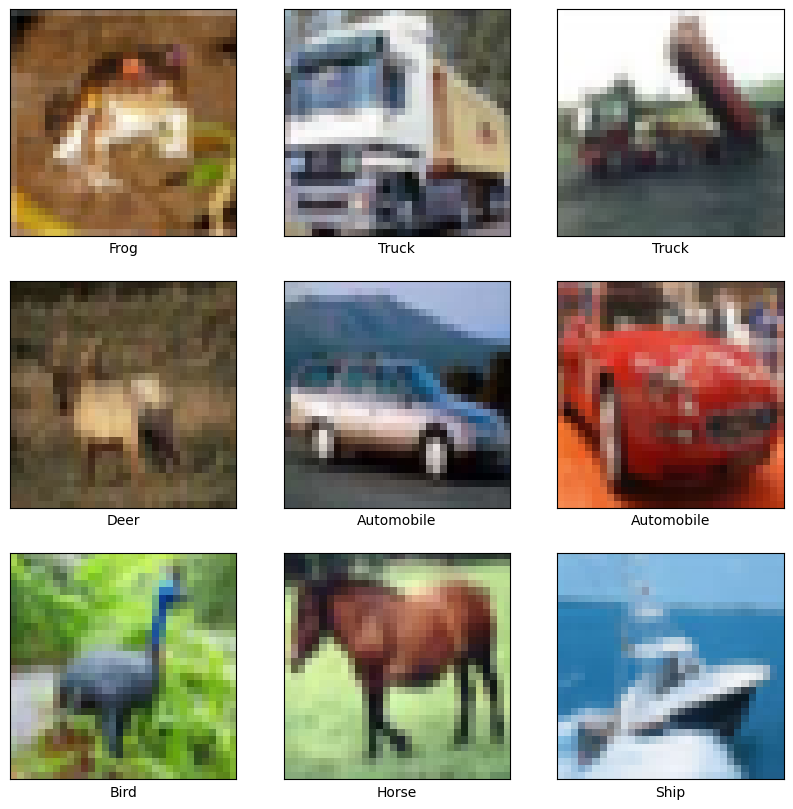

E:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.3028 - loss: 1.8816 - val_accuracy: 0.5319 - val_loss: 1.2995
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5171 - loss: 1.3528 - val_accuracy: 0.5822 - val_loss: 1.1642
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5800 - loss: 1.1925 - val_accuracy: 0.6400 - val_loss: 1.0184
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6246 - loss: 1.0682 - val_accuracy: 0.6581 - val_loss: 0.9833
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.6522 - loss: 0.9978 - val_accuracy: 0.6823 - val_loss: 0.8966
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.6839 - loss: 0.9192 - val_accuracy: 0.6946 - val_loss: 0.8725
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.6989 - loss: 0.8678 - val_accuracy: 0.7044 - val_loss: 0.8608
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7147 - loss: 0.8131 - 

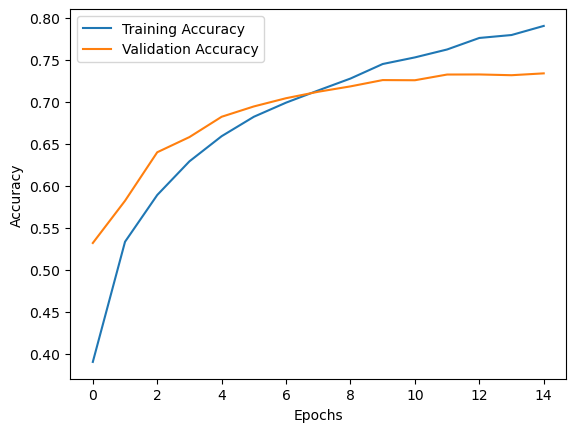

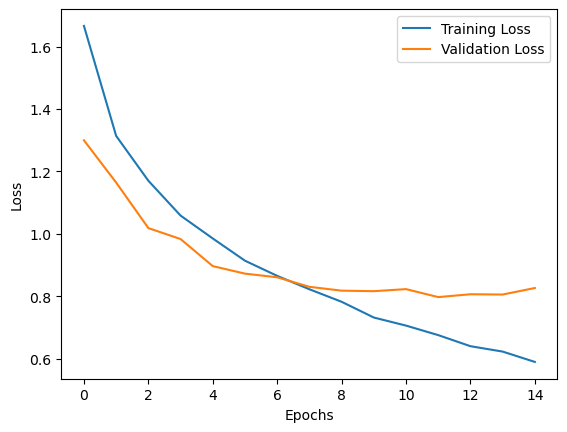

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
The image is predicted to be: Dog


In [1]:
#deep learning projects 
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to the range 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Class names for CIFAR-10 dataset
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Visualize some training images with labels
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[np.argmax(y_train[i])])
plt.show()

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 classes in CIFAR-10
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the trained model
model.save('cifar10_cnn_model.h5')

# Predict on a single image from the test set
def predict_image(img):
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)
    predicted_class = class_names[np.argmax(prediction)]
    print(f"The image is predicted to be: {predicted_class}")

# Test the prediction function with the first image in the test set
predict_image(X_test[0])


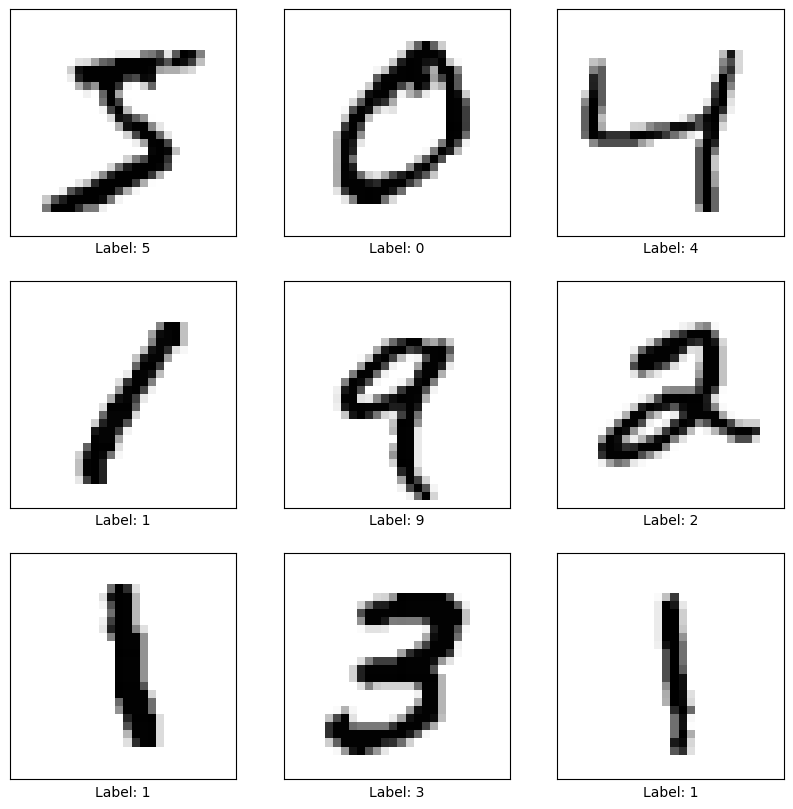

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.8375 - loss: 0.5167 - val_accuracy: 0.9845 - val_loss: 0.0466
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9723 - loss: 0.0922 - val_accuracy: 0.9874 - val_loss: 0.0360
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9804 - loss: 0.0631 - val_accuracy: 0.9880 - val_loss: 0.0356
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9846 - loss: 0.0511 - val_accuracy: 0.9906 - val_loss: 0.0285
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9868 - loss: 0.0442 - val_accuracy: 0.9917 - val_loss: 0.0291
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9877 - loss: 0.0376 - val_accuracy: 0.9916 - val_loss: 0.0294
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9898 - loss: 0.0329 - val_accuracy: 0.9926 - val_loss: 0.0233
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9906 - loss: 0.0295 - 

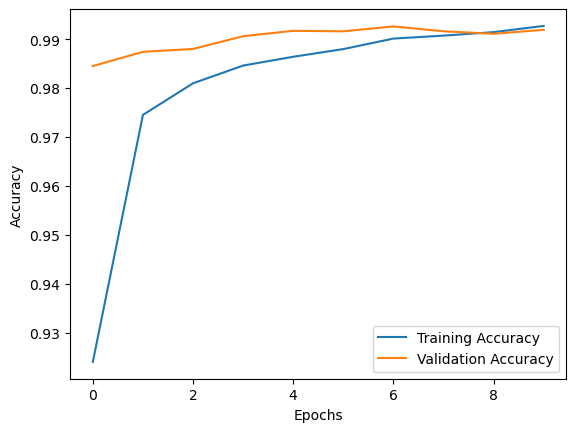

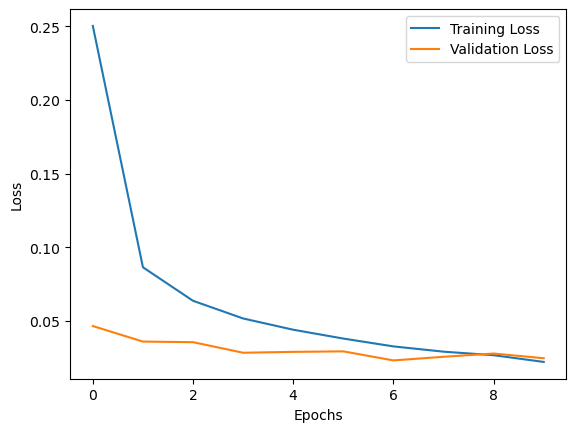

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted class: [0 0 0 0 0 0 0 0 0 0]


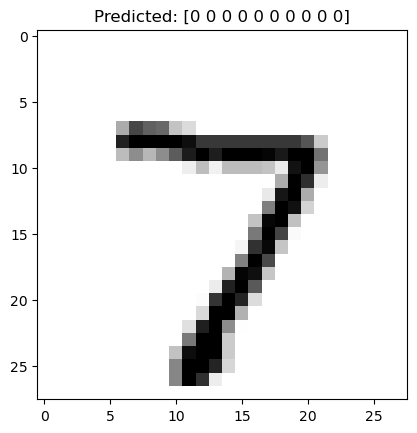

In [2]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to the range 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape data to add channel dimension (grayscale images)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Visualize some training images with labels
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i].reshape(28, 28), cmap=plt.cm.binary)
    plt.xlabel(f"Label: {tf.argmax(y_train[i]).numpy()}")
plt.show()

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 digits (0-9)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the trained model
model.save('mnist_cnn_model.h5')

# Predict on a single image from the test set
import numpy as np

def predict_image(img):
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    prediction = model.predict(img)
    predicted_class = tf.argmax(prediction).numpy()
    print(f"Predicted class: {predicted_class}")

    # Display the image
    plt.imshow(img.squeeze(), cmap=plt.cm.binary)
    plt.title(f"Predicted: {predicted_class}")
    plt.show()

# Test the prediction function with the first image in the test set
predict_image(X_test[0])


Sample data from the Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa  


C:\Users\Asus\AppData\Local\Temp\ipykernel_11392\3666006252.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=iris_data, x='species_name', palette='viridis')


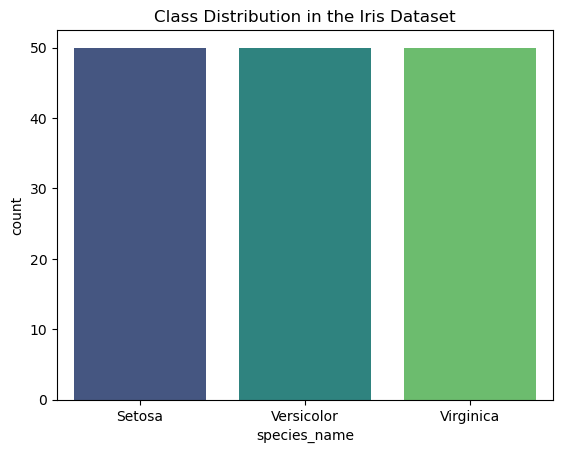

Accuracy of Random Forest Classifier: 88.89%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



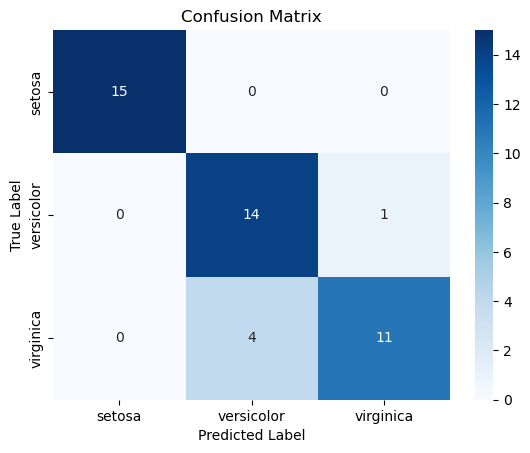

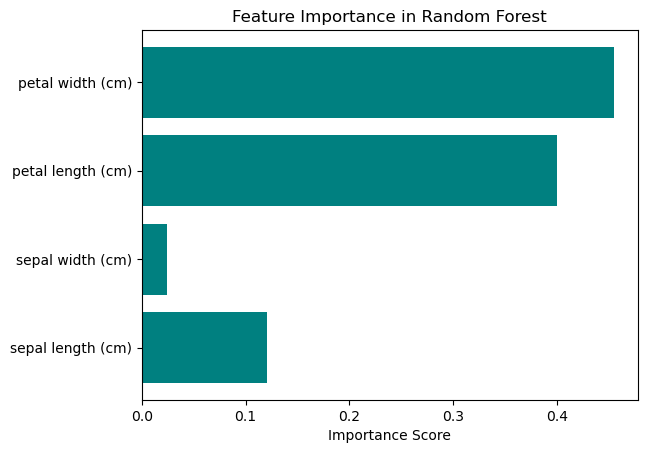

Predicted species for the sample [[5.1 3.5 1.4 0.2]]: setosa


E:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.DataFrame(iris.target, columns=["species"])

# Combine features and target for visualization
iris_data = pd.concat([X, y], axis=1)

# Add species names for better readability
iris_data['species_name'] = iris_data['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

# Visualize the dataset
print("Sample data from the Iris dataset:")
print(iris_data.head())

# Visualize class distribution
sns.countplot(data=iris_data, x='species_name', palette='viridis')
plt.title("Class Distribution in the Iris Dataset")
plt.show()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize the feature values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train.values.ravel())

# Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Random Forest Classifier: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Feature importance
feature_importance = rf_model.feature_importances_
plt.barh(X.columns, feature_importance, color='teal')
plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance Score")
plt.show()

# Test the model with a new sample
sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example for a Setosa
sample_scaled = scaler.transform(sample)
prediction = rf_model.predict(sample_scaled)
print(f"Predicted species for the sample {sample}: {iris.target_names[prediction[0]]}")


Sample Data:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa  


C:\Users\Asus\AppData\Local\Temp\ipykernel_11392\3236135805.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=iris_data, x='species_name', palette='viridis')


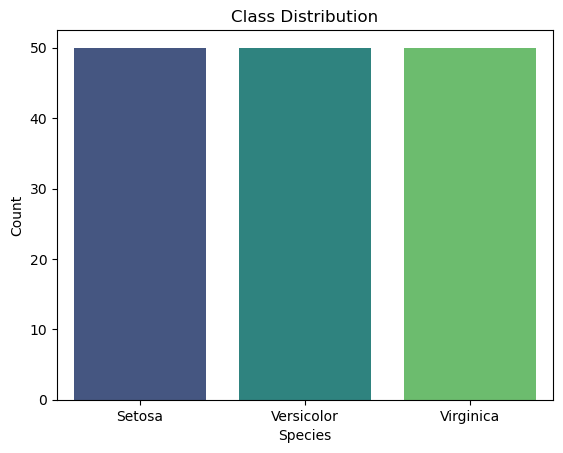

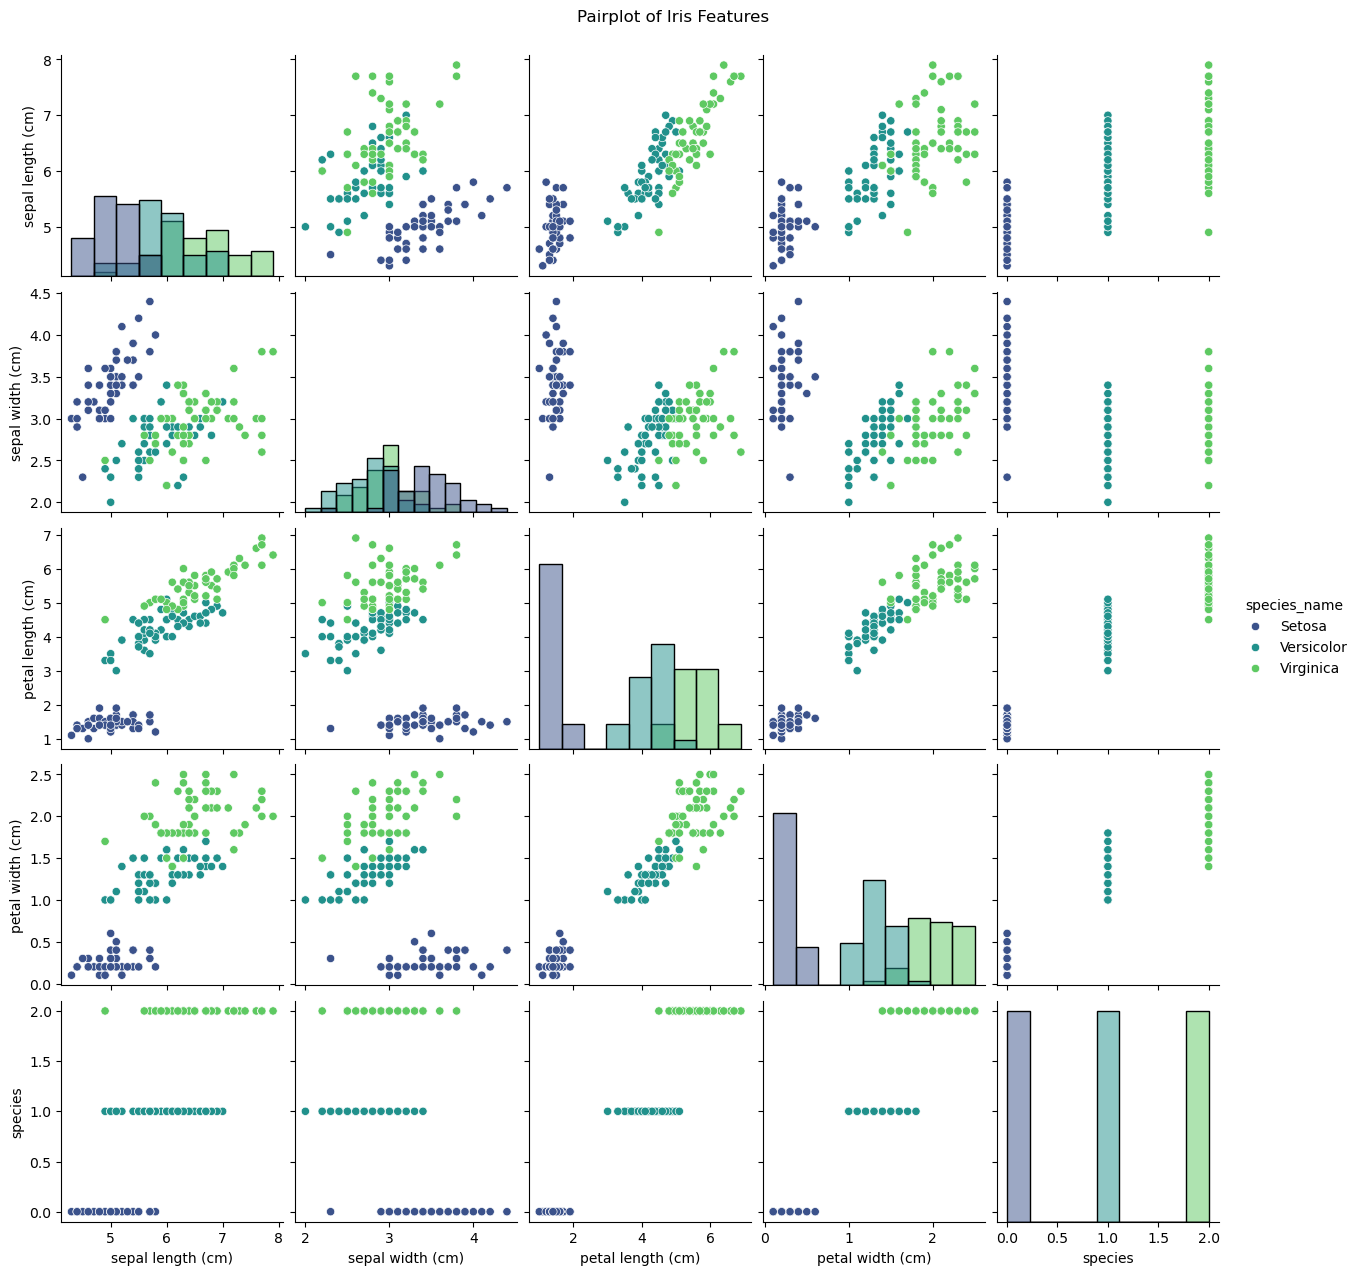

Model Accuracy: 88.89%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



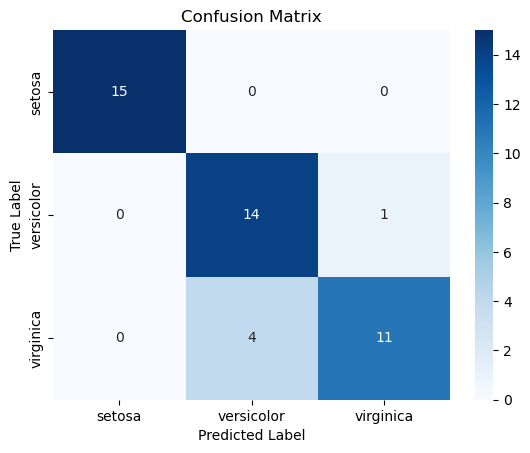

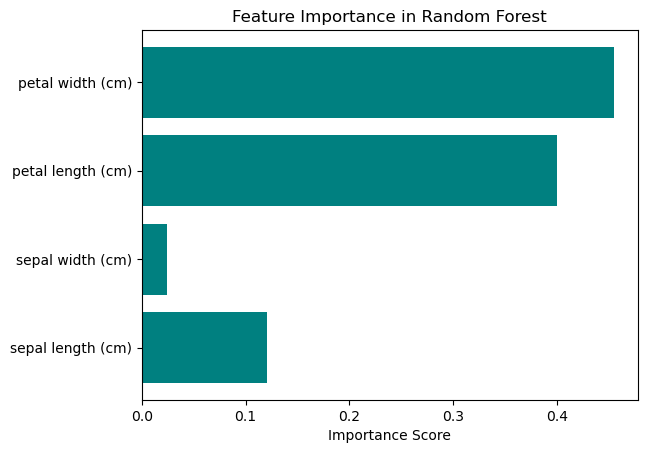

Predicted species for the sample [[5.1 3.5 1.4 0.2]]: setosa


E:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Iris dataset
from sklearn.datasets import load_iris
iris = load_iris()

# Create a DataFrame from the dataset
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.DataFrame(iris.target, columns=['species'])

# Combine features and target for visualization
iris_data = pd.concat([X, y], axis=1)
iris_data['species_name'] = iris_data['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

# Display the first few rows of the dataset
print("Sample Data:")
print(iris_data.head())

# Visualize the class distribution
sns.countplot(data=iris_data, x='species_name', palette='viridis')
plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# Pairplot to visualize relationships between features
sns.pairplot(iris_data, hue='species_name', diag_kind='hist', palette='viridis')
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

# Define features and target variable
X = iris_data.drop(columns=['species', 'species_name'])
y = iris_data['species']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Feature importance
feature_importance = rf_model.feature_importances_
features = X.columns
plt.barh(features, feature_importance, color='teal')
plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance Score")
plt.show()

# Test the model with a new sample
sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example for Setosa
sample_scaled = scaler.transform(sample)
prediction = rf_model.predict(sample_scaled)
print(f"Predicted species for the sample {sample}: {iris.target_names[prediction[0]]}")


In [5]:
a=2
print(a)

2


In [6]:
type(a)

int

In [7]:
b=4.5
b

4.5

In [8]:
type(b)

float

In [9]:
b="string literal"
b

'string literal'

In [10]:
type(b)

str

In [11]:
c=[1,2,3,4.5,5,6.6]
c

[1, 2, 3, 4.5, 5, 6.6]

In [12]:
c.append("aiml")
c

[1, 2, 3, 4.5, 5, 6.6, 'aiml']

In [13]:
c

[1, 2, 3, 4.5, 5, 6.6, 'aiml']

In [14]:
c

[1, 2, 3, 4.5, 5, 6.6, 'aiml']

In [15]:
type(c)

list

In [16]:
c.append("dsai")
c

[1, 2, 3, 4.5, 5, 6.6, 'aiml', 'dsai']

In [17]:
c

[1, 2, 3, 4.5, 5, 6.6, 'aiml', 'dsai']

In [18]:
tup1 = (1,2,3,4)
tup1

(1, 2, 3, 4)

In [19]:
type(tup1)

tuple

In [20]:
for i in range(1,14):
    print(i)

1
2
3
4
5
6
7
8
9
10
11
12
13


In [21]:
i=0
while(i<14):
    print(i)
    i=i+1

0
1
2
3
4
5
6
7
8
9
10
11
12
13


In [22]:
c

[1, 2, 3, 4.5, 5, 6.6, 'aiml', 'dsai']

In [23]:
type(b)

str

In [24]:
s1 = {1,2,3,"ai"}
s1


      

{1, 2, 3, 'ai'}

In [25]:
type(s1)

set

In [26]:
s1.add(12)
s1

{1, 12, 2, 3, 'ai'}

In [27]:
s1.add("mlops")
s1

{1, 12, 2, 3, 'ai', 'mlops'}

In [28]:
dict1 = {1:"apple" , 2:"banana" ,3:"Mango"}
dict1

{1: 'apple', 2: 'banana', 3: 'Mango'}

In [29]:
type(dict1)

dict

In [30]:
dict1.get(1)

'apple'

In [31]:
dict1.get("apple")
dict1

{1: 'apple', 2: 'banana', 3: 'Mango'}

In [32]:
dict1.get("apple")

In [33]:
dict1

{1: 'apple', 2: 'banana', 3: 'Mango'}

In [34]:
dict1.get(2)

'banana'

In [35]:
dict1.keys()

dict_keys([1, 2, 3])

In [36]:
dict1.items()

dict_items([(1, 'apple'), (2, 'banana'), (3, 'Mango')])

In [37]:
dict1.values()

dict_values(['apple', 'banana', 'Mango'])

In [38]:
dict1.get(3)

'Mango'

In [39]:
dict1["apple"]


KeyError: 'apple'

In [40]:
dict1

{1: 'apple', 2: 'banana', 3: 'Mango'}

In [41]:
dict1["apple"]
dict1

KeyError: 'apple'

In [42]:
dict1.get("apple")
dict1

{1: 'apple', 2: 'banana', 3: 'Mango'}